## 1. Imports and Configuration

In [2]:
# [IMPORTS]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, roc_auc_score
import os

In [3]:
# [CONFIG]
TRAIN_FILE    = '../../data/processed/clinical_merged/train_beta_5e5.csv'
VAL_FILE      = '../../data/processed/clinical_merged/val_beta_5e5.csv'
KL_FILE       = '../../data/baseline/kl_divergence_beta_5.00e-05.csv'
OUTPUT_DIR    = '../../results/lasso/'
FIGURES_DIR   = '../../results/figures/'
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

PATIENT_COL  = 'PATNO'
LABEL_COL    = 'label'
RANDOM_STATE = 42
N_FOLDS      = 5

# Active dimensions from KL divergence
df_kl       = pd.read_csv(KL_FILE)
ACTIVE_DIMS = df_kl[df_kl['mean_kl'] > 0.05]['dimension'].tolist()

# Tasks to analyse
TASKS = {
    'age_hc':      {'target': 'AGE_AT_VISIT',     'type': 'regression',     'subset': 'HC'},
    'pd_hc':       {'target': 'label',             'type': 'classification', 'subset': 'PD_HC'},
    'bradyrig':    {'target': 'AI_BradyRig_Diff',  'type': 'regression',     'subset': 'PD'},
    'tremor':      {'target': 'AI_Tremor_Diff',    'type': 'regression',     'subset': 'PD'},
    'np3tot':      {'target': 'UPDRS3_TOTAL',      'type': 'regression',     'subset': 'PD'},
}

print(f"Active dimensions: {len(ACTIVE_DIMS)}")
print(f"Tasks: {list(TASKS.keys())}")


Active dimensions: 50
Tasks: ['age_hc', 'pd_hc', 'bradyrig', 'tremor', 'np3tot']


## 2. Load Data

In [4]:
# [LOAD-DATA]

df_train = pd.read_csv(TRAIN_FILE)
df_val   = pd.read_csv(VAL_FILE)


# Convert Sex to binary
df_train['SEX'] = df_train['Sex'].map({'F': 0, 'M': 1})
df_val['SEX']   = df_val['Sex'].map({'F': 0, 'M': 1})

# Create subsets for each tasks:- HC subset — used for Task A (age in HC)
                               #- PD subset — used for Tasks C, D, E (BradyRig_Diff, Tremor_Diff, NP3TOT)
                               #- PD_HC subset — used for Task B (PD vs HC separation)
subsets_train = {
    'HC':    df_train[df_train[LABEL_COL] == 'Control'].copy(),
    'PD':    df_train[df_train[LABEL_COL] == 'PD'].copy(),
    'PD_HC': df_train[df_train[LABEL_COL].isin(['PD', 'Control'])].copy()
}

subsets_val = {
    'HC':    df_val[df_val[LABEL_COL] == 'Control'].copy(),
    'PD':    df_val[df_val[LABEL_COL] == 'PD'].copy(),
    'PD_HC': df_val[df_val[LABEL_COL].isin(['PD', 'Control'])].copy()
}

# Add binary label for classification
for d in [subsets_train, subsets_val]:
    for k in d:
        d[k]['label_binary'] = (d[k][LABEL_COL] == 'PD').astype(int)

print("=== Dataset ===")
for k, v in subsets_train.items():
    print(f"  Train {k}: {len(v)} rows, {v[PATIENT_COL].nunique()} patients")
print()
for k, v in subsets_val.items():
    print(f"  Val {k}:   {len(v)} rows, {v[PATIENT_COL].nunique()} patients")

print(f"\nActive dims available: {all(d in df_train.columns for d in ACTIVE_DIMS)}")


=== Dataset ===
  Train HC: 313 rows, 308 patients
  Train PD: 2666 rows, 1310 patients
  Train PD_HC: 2979 rows, 1618 patients

  Val HC:   65 rows, 64 patients
  Val PD:   688 rows, 337 patients
  Val PD_HC:   753 rows, 401 patients

Active dims available: True


## 3. LASSO CV
What it does: For each task, runs Lasso with cross-validation to find the optimal regularisation strength, then identifies which dimensions are selected and how many are needed.

In [5]:
# [LASSO-CV]

def run_lasso_task(df_tr, df_vl, task_name, task_info):
    target    = 'label_binary' if task_info['type'] == 'classification' else task_info['target']
    is_clf    = task_info['type'] == 'classification'
    feat_cols = ACTIVE_DIMS + (['SEX', 'AGE_AT_VISIT'] if is_clf else [])
    feat_cols = [c for c in feat_cols if c in df_tr.columns]

    data_tr = df_tr[feat_cols + [target, PATIENT_COL]].dropna()
    data_vl = df_vl[feat_cols + [target, PATIENT_COL]].dropna()

    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(data_tr[feat_cols].values)
    X_vl    = scaler.transform(data_vl[feat_cols].values)
    y_tr    = data_tr[target].values
    y_vl    = data_vl[target].values

    # Patient-stratified CV splits
    patients = data_tr[PATIENT_COL].unique()
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_splits = [
        (np.where(data_tr[PATIENT_COL].isin(patients[tr]))[0],
         np.where(data_tr[PATIENT_COL].isin(patients[vl]))[0])
        for tr, vl in kf.split(patients)
    ]

    if is_clf:
        model = LogisticRegressionCV(cv=cv_splits, penalty='l1',
                                     solver='saga', max_iter=5000,
                                     random_state=RANDOM_STATE)
        model.fit(X_tr, y_tr)
        score  = roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1])
        metric = 'AUC'
        coef   = dict(zip(feat_cols, model.coef_.flatten()))
    else:
        model = LassoCV(cv=cv_splits, max_iter=5000, random_state=RANDOM_STATE)
        model.fit(X_tr, y_tr)
        score  = r2_score(y_vl, model.predict(X_vl))
        metric = 'R²'
        coef   = dict(zip(feat_cols, model.coef_))

    selected = {d: coef[d] for d in ACTIVE_DIMS if abs(coef.get(d, 0)) > 1e-6}

    print(f"  {task_name}: {len(selected)}/{len(ACTIVE_DIMS)} dims selected, val {metric}={score:.3f}")
    top5 = sorted(selected.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    for dim, c in top5:
        print(f"    {dim}: {c:.4f}")
    print()

    return {'task': task_name, 'n_selected': len(selected),
            'score': score, 'metric': metric, 'coef': coef, 'selected': selected}

print("=== Lasso CV ===\n")
results = {}
for task_name, task_info in TASKS.items():
    results[task_name] = run_lasso_task(
        subsets_train[task_info['subset']],
        subsets_val[task_info['subset']],
        task_name, task_info
    )



=== Lasso CV ===

  age_hc: 33/50 dims selected, val R²=0.453
    latent_222: 3.3370
    latent_114: 3.0386
    latent_214: -2.1912
    latent_113: 1.9012
    latent_192: -1.8704

  pd_hc: 30/50 dims selected, val AUC=0.988
    latent_132: 1.5905
    latent_15: 0.9397
    latent_3: -0.7878
    latent_31: 0.7845
    latent_145: 0.4886

  bradyrig: 31/50 dims selected, val R²=0.608
    latent_173: 1.5026
    latent_7: -1.4061
    latent_141: 1.2653
    latent_113: -1.1418
    latent_218: 1.0456

  tremor: 30/50 dims selected, val R²=0.416
    latent_7: -0.5871
    latent_15: 0.5460
    latent_232: -0.5238
    latent_173: 0.4900
    latent_218: 0.4096

  np3tot: 25/50 dims selected, val R²=0.067
    latent_132: 3.1203
    latent_31: 0.8742
    latent_222: 0.8187
    latent_232: 0.7746
    latent_218: -0.7508



## 4. Cross-Task Overlap

What it does: Identifies which dimensions are selected across multiple tasks — these are the most universally important dimensions in the VAE.

In [6]:
# Get selected dims per task
selected_per_task = {
    task: set(r['selected'].keys())
    for task, r in results.items() if r is not None
}
# print(selected_per_task.keys())  

# Count how many tasks each dim appears in
dim_task_count = {}
for dim in ACTIVE_DIMS:
    count = sum(1 for task_dims in selected_per_task.values() if dim in task_dims)

    ## Check in which tasks the latent exist
    # for task_dims in selected_per_task.items():
    #      if dim in task_dims[1]:
    #         print(dim, task_dims[0])

    if count > 0:
        dim_task_count[dim] = count
# print(dim_task_count)   

# Sort by count
dim_task_count = dict(sorted(dim_task_count.items(),
                              key=lambda x: x[1], reverse=True))
                              
print(f"{'Dimension':<15} {'Tasks':>6} {'Which tasks'}")
print("-" * 60)
for dim, count in dim_task_count.items():
    tasks_list = [t for t, s in selected_per_task.items() if dim in s]
    print(f"  {dim:<13} {count:>6}   {', '.join(tasks_list)}")

# Dims appearing in all 5 tasks
all_tasks = [d for d, c in dim_task_count.items() if c == 5]
print(f"\nDims in ALL 5 tasks: {len(all_tasks)} — {all_tasks}")

# Dims appearing in 4+ tasks
four_plus = [d for d, c in dim_task_count.items() if c >= 4]
print(f"Dims in 4+ tasks:    {len(four_plus)} — {four_plus}")

# Dims appearing in 3+ tasks
three_plus = [d for d, c in dim_task_count.items() if c >= 3]
print(f"Dims in 3+ tasks:    {len(three_plus)} — {three_plus}")


Dimension        Tasks Which tasks
------------------------------------------------------------
  latent_31          5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_132         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_162         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_218         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_227         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_8           4   age_hc, pd_hc, tremor, np3tot
  latent_10          4   age_hc, bradyrig, tremor, np3tot
  latent_70          4   age_hc, pd_hc, tremor, np3tot
  latent_83          4   age_hc, pd_hc, bradyrig, tremor
  latent_86          4   age_hc, pd_hc, bradyrig, np3tot
  latent_113         4   age_hc, pd_hc, bradyrig, tremor
  latent_114         4   age_hc, pd_hc, bradyrig, np3tot
  latent_133         4   age_hc, bradyrig, tremor, np3tot
  latent_141         4   age_hc, pd_hc, bradyrig, tremor
  latent_145         4   age_hc, pd_hc, bradyrig, tremor
  latent_17

## 5. Dimension Importance Visualisation

What it does: Two plots:

Bar chart showing how many tasks each dimension appears in
Heatmap showing coefficient magnitude per dimension per task

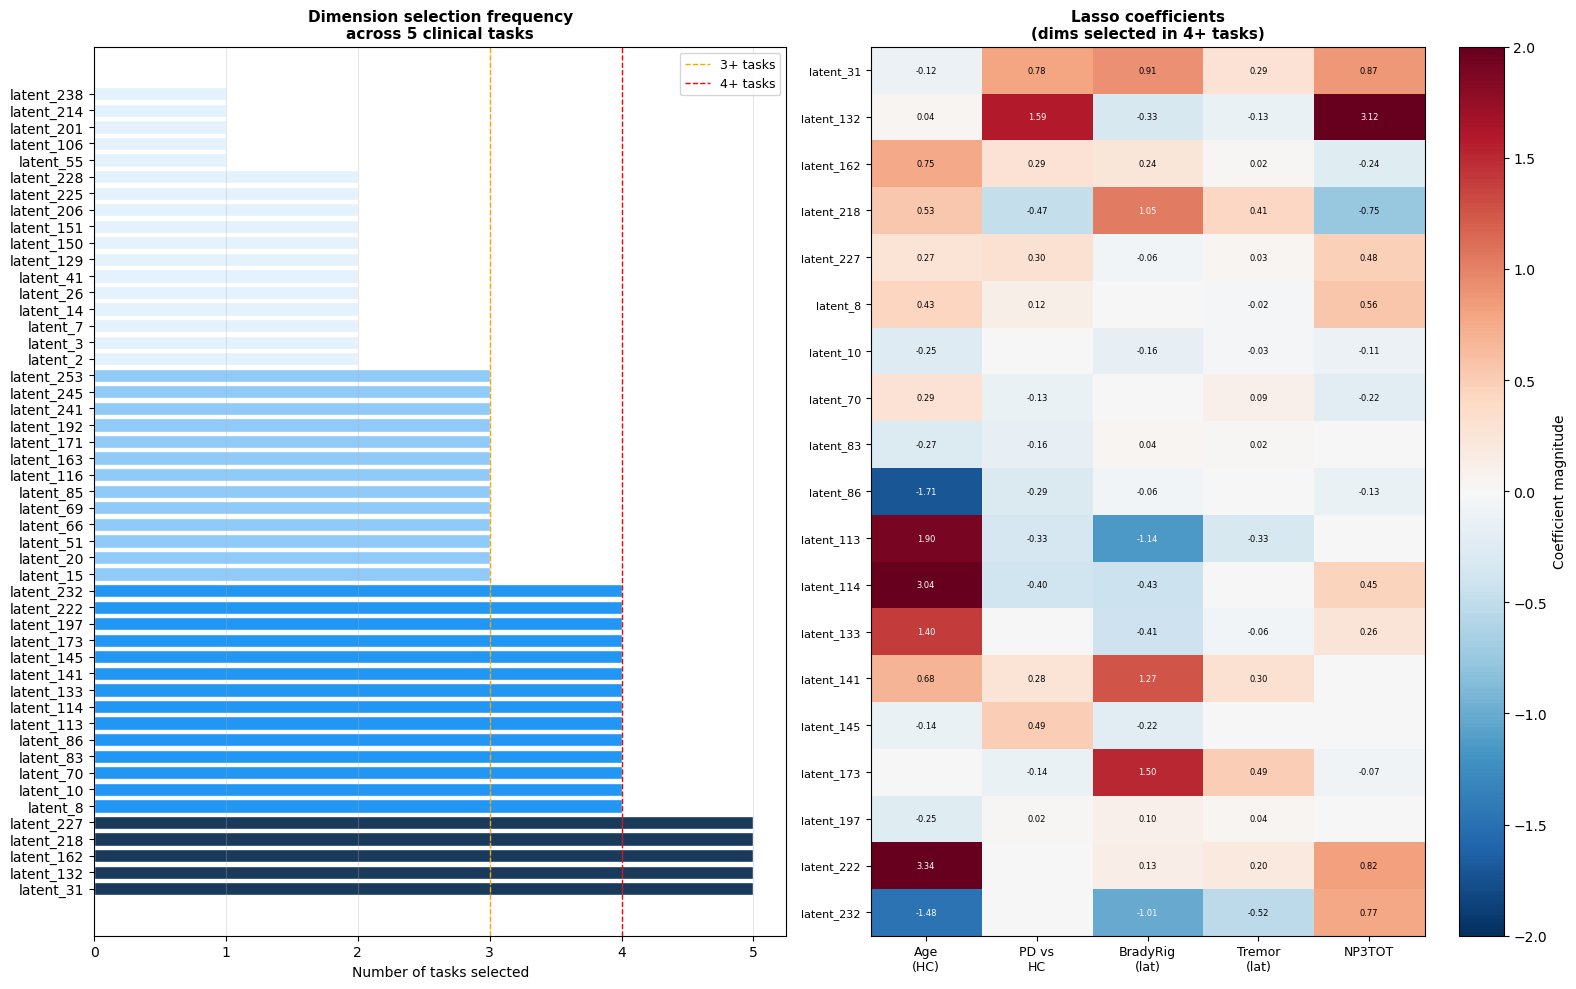

Saved: ../../results/figures/lasso_importance_beta_5e5.png


In [7]:
# [VISUALISATION]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# ── Plot 1 — Task count per dimension ────────────────────────────
ax = axes[0]
dims_sorted = list(dim_task_count.keys())
counts      = [dim_task_count[d] for d in dims_sorted]
colors      = ['#1a3a5c' if c == 5 else
               '#2196F3' if c >= 4 else
               '#90CAF9' if c >= 3 else
               '#E3F2FD' for c in counts]

ax.barh(dims_sorted, counts, color=colors, edgecolor='white')
ax.axvline(3, color='orange', linestyle='--', linewidth=1, label='3+ tasks')
ax.axvline(4, color='red',    linestyle='--', linewidth=1, label='4+ tasks')
ax.set_xlabel('Number of tasks selected', fontsize=10)
ax.set_title('Dimension selection frequency\nacross 5 clinical tasks', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# ── Plot 2 — Coefficient heatmap ─────────────────────────────────
ax = axes[1]
task_names = list(results.keys())
dims_4plus = [d for d, c in dim_task_count.items() if c >= 4]

coef_matrix = np.zeros((len(dims_4plus), len(task_names)))
for j, task in enumerate(task_names):
    if results[task] is None:
        continue
    for i, dim in enumerate(dims_4plus):
        coef_matrix[i, j] = results[task]['coef'].get(dim, 0)

im = ax.imshow(coef_matrix, cmap='RdBu_r', aspect='auto',
               vmin=-2, vmax=2)
ax.set_xticks(range(len(task_names)))
ax.set_xticklabels(['Age\n(HC)', 'PD vs\nHC', 'BradyRig\n(lat)', 
                    'Tremor\n(lat)', 'NP3TOT'], fontsize=9)
ax.set_yticks(range(len(dims_4plus)))
ax.set_yticklabels(dims_4plus, fontsize=8)
ax.set_title('Lasso coefficients\n(dims selected in 4+ tasks)', 
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Coefficient magnitude')

# Add text values
for i in range(len(dims_4plus)):
    for j in range(len(task_names)):
        val = coef_matrix[i, j]
        if abs(val) > 0.01:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                   fontsize=6, color='white' if abs(val) > 1 else 'black')

plt.tight_layout()
path = f'{FIGURES_DIR}lasso_importance_beta_5e5.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

## 8. Stability Selection

In [8]:
# [STABILITY-SELECTION]

from sklearn.linear_model import Lasso, LogisticRegression
import warnings
warnings.filterwarnings('ignore')

N_BOOTSTRAP   = 100
SUBSAMPLE_FRAC = 0.5
THRESHOLD      = 0.6  # 60% selection frequency

def stability_selection(df_tr, task_name, task_info, n_bootstrap=N_BOOTSTRAP):
    target   = 'label_binary' if task_info['type'] == 'classification' else task_info['target']
    is_clf   = task_info['type'] == 'classification'
    feat_cols = ACTIVE_DIMS + (['SEX', 'AGE_AT_VISIT'] if is_clf else [])
    feat_cols = [c for c in feat_cols if c in df_tr.columns]

    data = df_tr[feat_cols + [target, PATIENT_COL]].dropna()
    unique_patients = data[PATIENT_COL].unique()
    print(unique_patients)

    # Count how many times each dim is selected
    selection_counts = {dim: 0 for dim in ACTIVE_DIMS}

    for _ in range(n_bootstrap):
        # Subsample patients
        n_sub = int(len(unique_patients) * SUBSAMPLE_FRAC)
        sub_patients = np.random.choice(unique_patients, n_sub, replace=False)
        sub_data = data[data[PATIENT_COL].isin(sub_patients)]

        X = sub_data[feat_cols].values
        y = sub_data[target].values

        scaler = StandardScaler()
        X_s    = scaler.fit_transform(X)

        try:
            if is_clf:
                model = LogisticRegression(
                    penalty='l1', solver='saga',
                    C=0.1, max_iter=2000, random_state=None
                )
                model.fit(X_s, y)
                coef = dict(zip(feat_cols, model.coef_.flatten()))
            else:
                model = Lasso(alpha=0.1, max_iter=2000)
                model.fit(X_s, y)
                coef = dict(zip(feat_cols, model.coef_))

            for dim in ACTIVE_DIMS:
                if abs(coef.get(dim, 0)) > 1e-6:
                    selection_counts[dim] += 1
        except:
            continue

    # Convert to probability
    selection_prob = {dim: count / n_bootstrap
                      for dim, count in selection_counts.items()}

    # Stable dims above threshold
    stable = {dim: prob for dim, prob in selection_prob.items()
              if prob >= THRESHOLD}

    print(f"  {task_name}: {len(stable)} stable dims (>{THRESHOLD*100:.0f}% frequency)")
    top5 = sorted(stable.items(), key=lambda x: x[1], reverse=True)[:5]
    for dim, prob in top5:
        print(f"    {dim}: {prob:.2f}")
    print()

    return selection_prob

print("=== Stability Selection (100 bootstrap runs) ===\n")
stability_results = {}
for task_name, task_info in TASKS.items():
    np.random.seed(RANDOM_STATE)
    stability_results[task_name] = stability_selection(
        subsets_train[task_info['subset']],
        task_name, task_info
    )

=== Stability Selection (100 bootstrap runs) ===

[  3405 187759   3300 364414   3813 179510 165043   3852 311116 120545
 293353 149006 142087   4007   3115   3668 102447   3651   3479 142086
 162516   3952 314240   3571   3016   3525   3219   3172   3466   3103
   3551   3768 160821 149005   3636   3353   3000 129031   4139   3615
   3478   3517   3460 313375   3656   3112 317115 359465   3481 249498
   3424   3565 162905   3004   3639   3554 233667 116337 366827   3901
   3576   3362   3779   3204   3274   3276   3908   3320   3075 292982
   3301   3151 103542 147406   3156   3635   3316 212409   3072   3202
   3013 171162   3318   3619 101747 100004 325723 119428   3390 167746
 106864 348808   3213 369670   3450 100890 106126   3351   3391   3215
   3169   3464 108909   3518 292898 325198 293057 187823 115698   3087
   3811 166840   3271 311138   3850   3458   3541   3217   3270   3216
 161329 128335   3171 141893   3950   3857   4100 101556 157434 225930
 106127   3662 317117   306

## 9. Cross-task stable dimensions

In [11]:
# [STABILITY-OVERLAP]

stable_per_task = {
    task: set(dim for dim, prob in probs.items() if prob >= THRESHOLD)
    for task, probs in stability_results.items()
}

dim_stable_count = {}
for dim in ACTIVE_DIMS:
    count = sum(1 for s in stable_per_task.values() if dim in s)
    if count > 0:
        dim_stable_count[dim] = count

dim_stable_count = dict(sorted(dim_stable_count.items(),
                                key=lambda x: x[1], reverse=True))

print("=== Stable dims across tasks ===\n")
print(f"{'Dimension':<15} {'Tasks':>6}  {'Which tasks'}")
print("-" * 60)
for dim, count in dim_stable_count.items():
    tasks_list = [t for t, s in stable_per_task.items() if dim in s]
    print(f"  {dim:<13} {count:>6}   {', '.join(tasks_list)}")

all_tasks = [d for d, c in dim_stable_count.items() if c == 5]
print(f"\nStable in ALL 5 tasks: {len(all_tasks)} — {all_tasks}")

four_plus = [d for d, c in dim_stable_count.items() if c >= 4]
print(f"Stable in 4+ tasks:    {len(four_plus)} — {four_plus}")

three_plus = [d for d, c in dim_stable_count.items() if c >= 3]
print(f"Stable in 3+ tasks:    {len(three_plus)} — {three_plus}")

=== Stable dims across tasks ===

Dimension        Tasks  Which tasks
------------------------------------------------------------
  latent_132         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_218         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_133         4   age_hc, bradyrig, tremor, np3tot
  latent_173         4   pd_hc, bradyrig, tremor, np3tot
  latent_206         4   pd_hc, bradyrig, tremor, np3tot
  latent_232         4   age_hc, bradyrig, tremor, np3tot
  latent_8           3   age_hc, pd_hc, np3tot
  latent_10          3   age_hc, pd_hc, np3tot
  latent_15          3   pd_hc, bradyrig, tremor
  latent_31          3   bradyrig, tremor, np3tot
  latent_66          3   age_hc, bradyrig, tremor
  latent_113         3   age_hc, bradyrig, tremor
  latent_114         3   age_hc, bradyrig, np3tot
  latent_141         3   age_hc, bradyrig, tremor
  latent_162         3   age_hc, bradyrig, np3tot
  latent_192         3   age_hc, pd_hc, np3tot
  latent_227       

## 10. Visualise stability probabilities

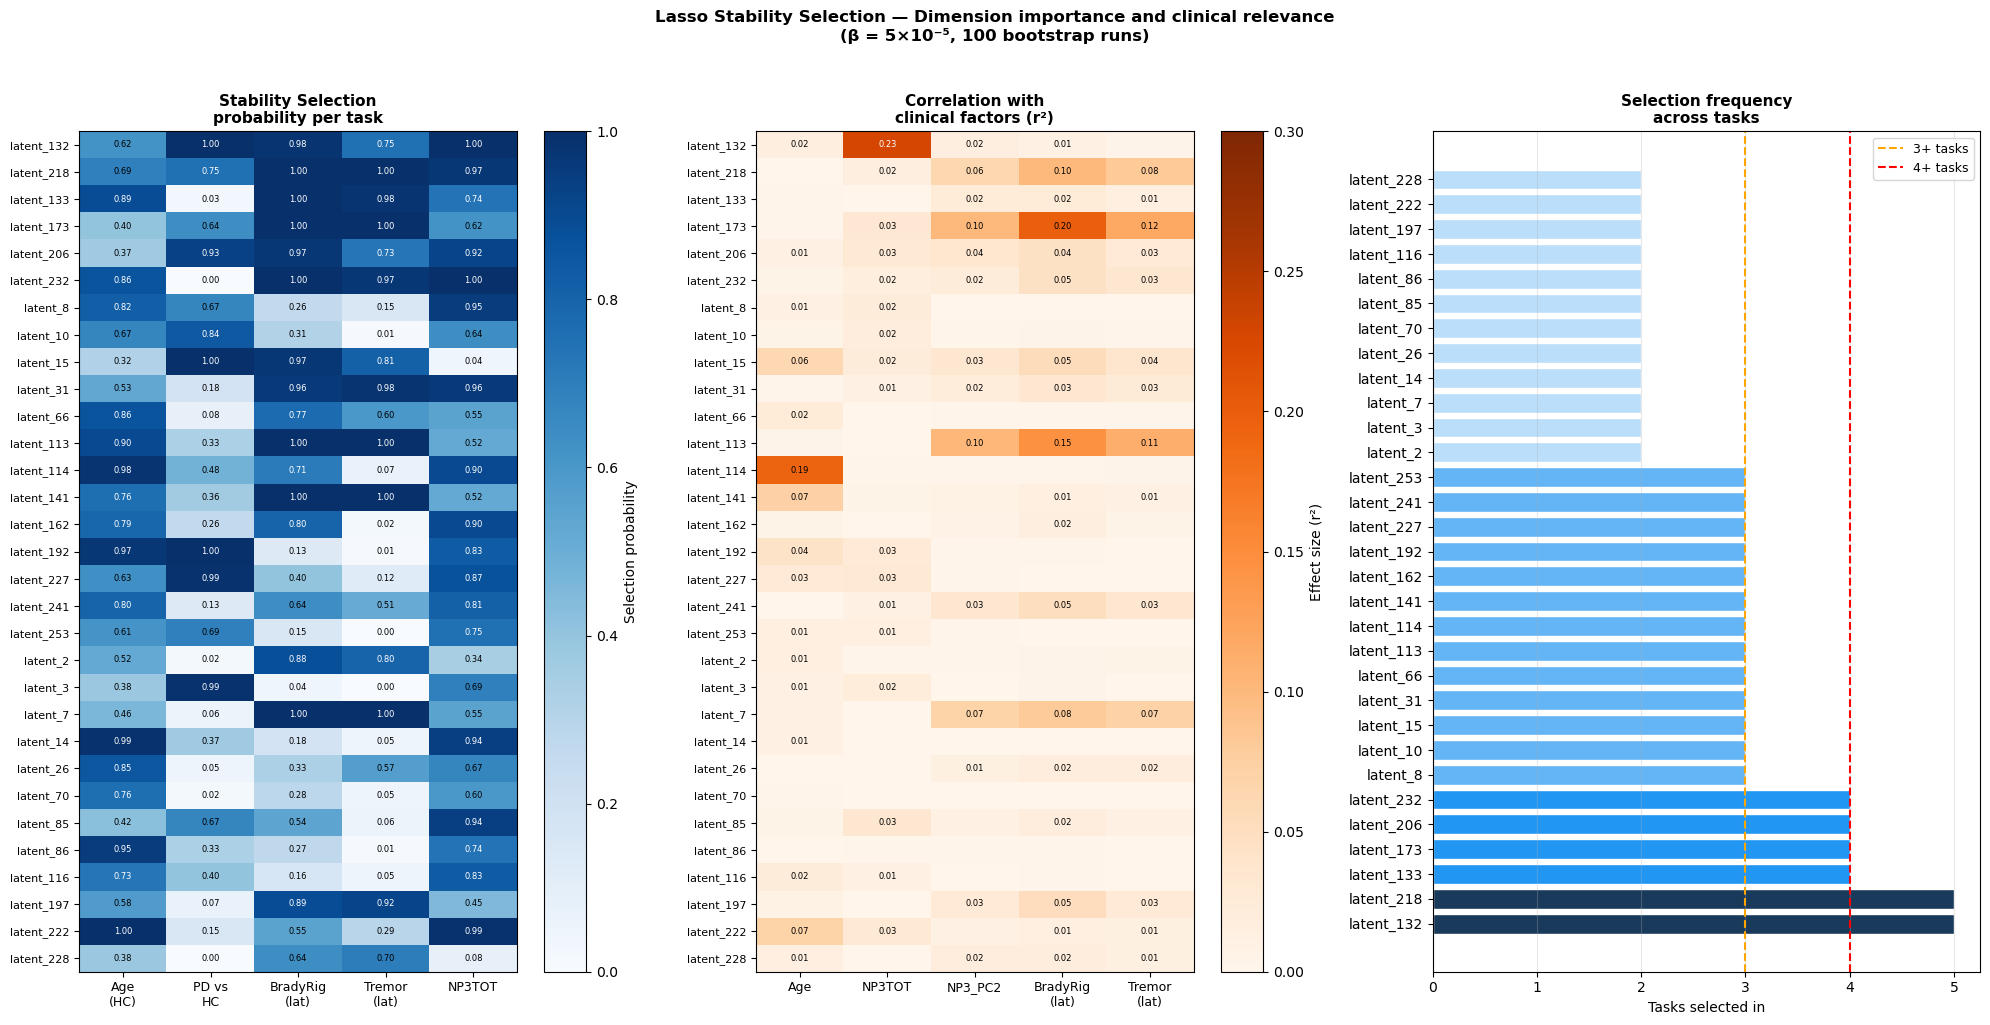

Saved: ../../results/figures/lasso_stability_comprehensive_beta_5e5.png


In [16]:
# [COMPREHENSIVE-VIZ]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# ── Plot 1 — Stability probability heatmap ───────────────────────
ax = axes[0]
dims_show = [d for d, c in dim_stable_count.items() if c >= 2]
task_labels = ['Age\n(HC)', 'PD vs\nHC', 'BradyRig\n(lat)', 
               'Tremor\n(lat)', 'NP3TOT']

prob_matrix = np.array([
    [stability_results[task].get(dim, 0) for task in TASKS.keys()]
    for dim in dims_show
])

im = ax.imshow(prob_matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(TASKS)))
ax.set_xticklabels(task_labels, fontsize=9)
ax.set_yticks(range(len(dims_show)))
ax.set_yticklabels(dims_show, fontsize=8)
ax.set_title('Stability Selection\nprobability per task', 
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Selection probability')

# Add threshold markers
for i in range(len(dims_show)):
    for j in range(len(TASKS)):
        val = prob_matrix[i, j]
        color = 'white' if val > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

# ── Plot 2 — Correlation with clinical factors ───────────────────
ax = axes[1]

# Load correlation results
df_corr = pd.read_csv('../../results/correlation/correlation_train_beta_5e5.csv')
clin_factors = ['AGE_AT_VISIT', 'UPDRS3_TOTAL', 'NP3_PC2',
                'AI_BradyRig_Diff', 'AI_Tremor_Diff']
clin_labels  = ['Age', 'NP3TOT', 'NP3_PC2', 'BradyRig\n(lat)', 'Tremor\n(lat)']

r2_matrix = np.zeros((len(dims_show), len(clin_factors)))
for i, dim in enumerate(dims_show):
    row = df_corr[df_corr['dimension'] == dim]
    if len(row) == 0:
        continue
    for j, factor in enumerate(clin_factors):
        col = f'{factor}_r2'
        if col in row.columns:
            r2_matrix[i, j] = row[col].values[0] or 0

im2 = ax.imshow(r2_matrix, cmap='Oranges', vmin=0, vmax=0.3, aspect='auto')
ax.set_xticks(range(len(clin_factors)))
ax.set_xticklabels(clin_labels, fontsize=9)
ax.set_yticks(range(len(dims_show)))
ax.set_yticklabels(dims_show, fontsize=8)
ax.set_title('Correlation with\nclinical factors (r²)',
             fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax, label='Effect size (r²)')

for i in range(len(dims_show)):
    for j in range(len(clin_factors)):
        val = r2_matrix[i, j]
        if val > 0.01:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if val > 0.2 else 'black')

# ── Plot 3 — Task count bar chart ────────────────────────────────
ax = axes[2]
counts = [dim_stable_count[d] for d in dims_show]
colors = ['#1a3a5c' if c == 5 else
          '#2196F3' if c >= 4 else
          '#64B5F6' if c >= 3 else
          '#BBDEFB' for c in counts]

ax.barh(dims_show, counts, color=colors, edgecolor='white')
ax.axvline(3, color='orange', linestyle='--', linewidth=1.5, label='3+ tasks')
ax.axvline(4, color='red',    linestyle='--', linewidth=1.5, label='4+ tasks')
ax.set_xlabel('Tasks selected in', fontsize=10)
ax.set_title('Selection frequency\nacross tasks',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Lasso Stability Selection — Dimension importance and clinical relevance\n(β = 5×10⁻⁵, 100 bootstrap runs)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
path = f'{FIGURES_DIR}lasso_stability_comprehensive_beta_5e5.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

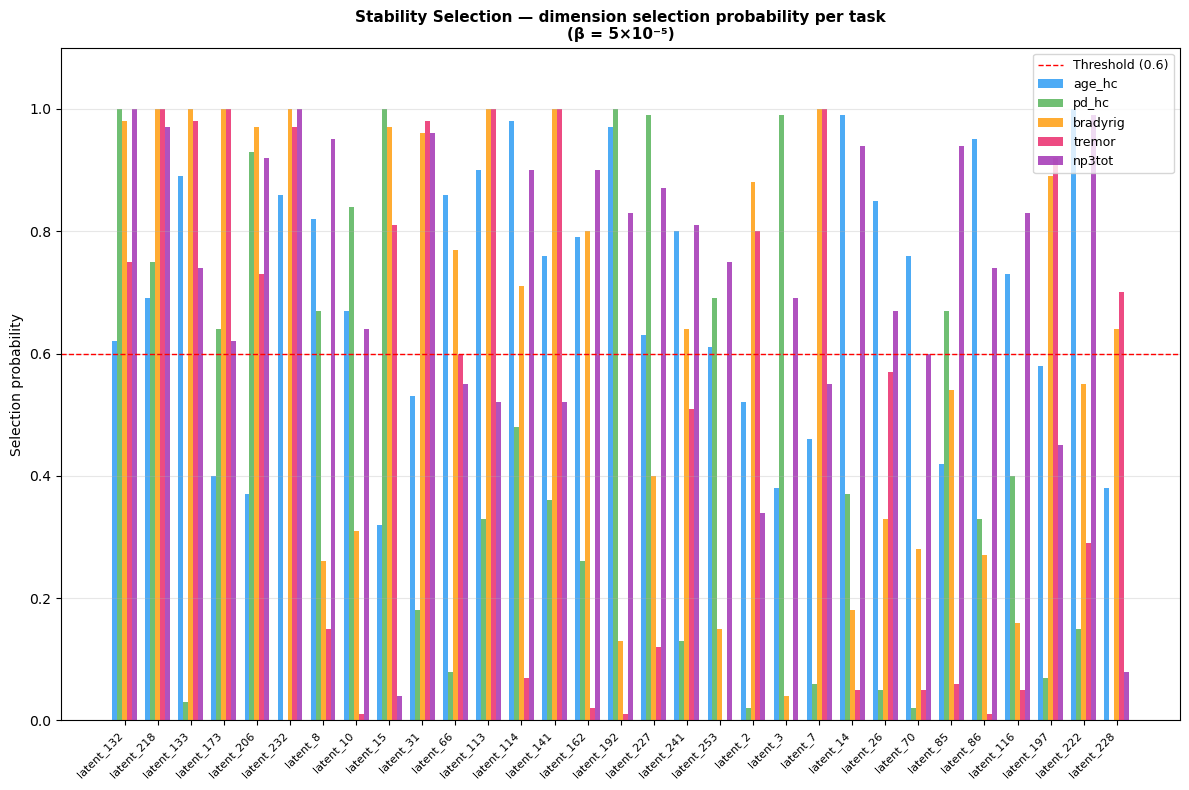

Saved: ../../results/figures/stability_selection_beta_5e5.png


In [12]:
# [STABILITY-PLOT]

fig, ax = plt.subplots(figsize=(12, 8))

task_colors = {
    'age_hc': '#2196F3', 'pd_hc': '#4CAF50',
    'bradyrig': '#FF9800', 'tremor': '#E91E63', 'np3tot': '#9C27B0'
}

# Show only dims stable in 2+ tasks
dims_show = [d for d, c in dim_stable_count.items() if c >= 2]
x = np.arange(len(dims_show))
width = 0.15

for j, (task, probs) in enumerate(stability_results.items()):
    vals = [probs.get(d, 0) for d in dims_show]
    ax.bar(x + j*width, vals, width, label=task,
           color=task_colors[task], alpha=0.8)

ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1,
           label=f'Threshold ({THRESHOLD})')
ax.set_xticks(x + width*2)
ax.set_xticklabels(dims_show, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Selection probability', fontsize=10)
ax.set_title('Stability Selection — dimension selection probability per task\n(β = 5×10⁻⁵)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
path = f'{FIGURES_DIR}stability_selection_beta_5e5.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")